# Inférence COCO sur images (dont panoramas 360°)

Ce notebook charge des **images locales** (fichier ou dossier), exécute :

1. **Détection d’objets COCO** — modèle **DETR** entraîné sur COCO (boîtes + libellés + scores).
2. **Classification globale d’image** — **ViT** entraîné sur **ImageNet-1k** (libellés *globaux* pour toute l’image ; ce n’est pas le même jeu de classes que COCO).
3. **Embeddings DINOv3** (optionnel) — modèle **Meta DINOv3** : vecteur global de scène + carte d’« énergie » des patchs (norme L2) pour visualiser où le backbone encode le plus d’information locale (pas de libellés sémantiques comme ImageNet).

Une section **Assets utilisés** détaille chaque ressource (poids, processeurs, labels, entrées/sorties).

## Assets utilisés (récapitulatif)

| Asset | Rôle | Source Hugging Face | Fichiers téléchargés (cache HF) |
|-------|------|---------------------|--------------------------------|
| **Poids DETR** | Réseau `DetrForObjectDetection` (backbone ResNet-50 + transformer decodeur) | `facebook/detr-resnet-50` | `pytorch_model.bin` ou `model.safetensors`, `config.json` |
| **Processor DETR** | Redimensionnement, normalisation ImageNet, tensorisation batch | même repo | `preprocessor_config.json` |
| **Labels COCO (détection)** | `id → nom de classe` (80 classes COCO) | embarqués dans `config.json` du modèle | champ `id2label` |
| **Poids ViT** | `ViTForImageClassification` (patch 16, 224×224) | `google/vit-base-patch16-224` | idem + poids |
| **Processor ViT** | Resize 224, normalisation du pré-entraînement ViT | même repo | `preprocessor_config.json` |
| **Labels ImageNet (classification)** | 1000 classes ImageNet | `config.json` du ViT | `id2label` |
| **DINOv3** | Backbone auto-supervisé : embedding global + features patch | p.ex. `facebook/dinov3-vits16-pretrain-lvd1689m` | poids + `preprocessor_config.json` |

**Entrée notebook :** chemins vers fichiers `.jpg`, `.jpeg`, `.png`, `.webp` (paramètre `INPUT_PATH`).

**Sorties :** dossier `inference_outputs/` — images annotées, `detections.json`, `classifications.json`, `dinov3_features.json` (si activé), PNG de cartes patch, plus une **visualisation interactive** dans le notebook (section *Visualisation de l'inférence*).

**DINOv3 sur Hugging Face :** les checkpoints Meta sont souvent **sous accord** (gated). Il faut accepter les conditions sur la page du modèle, puis `huggingface-cli login` ou variable d’environnement `HF_TOKEN`.

**Note 360° :** les modèles sont entraînés sur des vues **perspectives**. Une image **équirectangulaire** (rapport 2:1) est fortement déformée aux pôles ; le notebook propose un mode **découpage en bandes verticales** + fusion des détections (baseline).

## 1) Dépendances

Exécuter une fois si nécessaire (décommenter la ligne suivante dans la cellule code).

In [37]:
# Décommenter pour installer dans l'environnement courant :
# %pip install -q torch torchvision transformers pillow matplotlib numpy
# DINOv3 : transformers >= 4.56 recommandé

import io
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from matplotlib.patches import Rectangle
from transformers import (
    AutoImageProcessor,
    AutoModel,
    DetrForObjectDetection,
    DetrImageProcessor,
    ViTForImageClassification,
    ViTImageProcessor,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version.split()[0], "| torch:", torch.__version__, "| device:", DEVICE)

Python: 3.12.10 | torch: 2.10.0+cpu | device: cpu


## 2) Paramètres

- `INPUT_PATH` : un fichier image ou un dossier contenant des images.
- `SCORE_THRESHOLD_DETR` : seuil de confiance pour afficher / exporter une détection.
- `CLASSIFICATION_TOP_K` : nombre de classes ImageNet à conserver par image.
- `USE_360_STRIPS` : si `True` et image au ratio ~2:1, découpe en bandes verticales avant détection.
- `NUM_360_STRIPS` : nombre de bandes (ex. 4 ou 6).
- `ENABLE_DINOV3` / `DINOV3_MODEL_ID` : embeddings DINOv3 + export JSON / heatmaps (souvent **gated** sur Hugging Face).

In [38]:
# Répertoires : cwd = open3d_vision/src ou open3d_vision
_cwd = Path.cwd().resolve()
if (_cwd / "coco_inference_360.ipynb").exists():
    NB_DIR = _cwd
elif (_cwd / "src" / "coco_inference_360.ipynb").exists():
    NB_DIR = _cwd / "src"
else:
    NB_DIR = _cwd

INPUT_PATH = NB_DIR / Path(r"C:\Users\mvm\open3d_vision\data\ETL project data\Photos panos\00001-pano.jpg")
OUTPUT_DIR = NB_DIR / "inference_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DETR_MODEL_ID = "facebook/detr-resnet-50"
VIT_MODEL_ID = "google/vit-base-patch16-224"

SCORE_THRESHOLD_DETR = 0.7
CLASSIFICATION_TOP_K = 5

USE_360_STRIPS = True
NUM_360_STRIPS = 4
ERP_ASPECT_MIN = 1.7  # largeur/hauteur minimale pour considérer une image comme ERP 360 probable

# DINOv3 (Meta) — dépôt souvent *gated* sur HF : accepter l’accord + huggingface-cli login
ENABLE_DINOV3 = True
DINOV3_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("ENABLE_DINOV3:", ENABLE_DINOV3, "|", DINOV3_MODEL_ID if ENABLE_DINOV3 else "(désactivé)")

INPUT_PATH: C:\Users\mvm\open3d_vision\data\ETL project data\Photos panos\00001-pano.jpg
OUTPUT_DIR: C:\Users\mvm\open3d_vision\src\inference_outputs
ENABLE_DINOV3: True | facebook/dinov3-vits16-pretrain-lvd1689m


## 3) Chargement des images

In [39]:
def collect_image_paths(root: Path) -> list[Path]:
    root = root.expanduser().resolve()
    if not root.exists():
        raise FileNotFoundError(root)
    if root.is_file():
        if root.suffix.lower() not in IMAGE_EXTENSIONS:
            raise ValueError(f"Extension non supportée: {root.suffix}")
        return [root]
    paths = sorted(
        p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )
    return paths


def load_pil_rgb(path: Path) -> Image.Image:
    im = Image.open(path).convert("RGB")
    return im


image_paths = collect_image_paths(INPUT_PATH)
print(f"{len(image_paths)} image(s) trouvée(s)")
for p in image_paths[:10]:
    print(" -", p.name)
if len(image_paths) > 10:
    print(" ...")

1 image(s) trouvée(s)
 - 00001-pano.jpg


## 4) Détection COCO (DETR)

**Asset pipeline :** `DetrImageProcessor` prépare l’image (taille max, normalisation). `DetrForObjectDetection` prédit jusqu’à 100 requêtes ; le post-traitement HF filtre par seuil et convertit les boîtes en coordonnées pixel `[x1, y1, x2, y2]` pour chaque image.

In [40]:
detr_processor = DetrImageProcessor.from_pretrained(DETR_MODEL_ID)
detr_model = DetrForObjectDetection.from_pretrained(DETR_MODEL_ID).to(DEVICE)
detr_model.eval()

coco_id2label = detr_model.config.id2label
print("Nombre de classes COCO:", len(coco_id2label))
print("Exemple id2label:", {k: coco_id2label[k] for k in list(coco_id2label.keys())[:5]})

c:\Users\mvm\open3d_vision\.venv\Lib\site-packages\torch\nn\modules\module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
c:\Users\mvm\open3d_vision\.venv\Lib\site-packages\torch\nn\modules\batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
c:\Users\mvm\open3d_vision\.venv\Lib\site-packages\torch\nn\modules\batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta pa

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Nombre de classes COCO: 91
Exemple id2label: {0: 'N/A', 1: 'person', 10: 'traffic light', 11: 'fire hydrant', 12: 'street sign'}


In [41]:
def is_probably_equirectangular(im: Image.Image) -> bool:
    w, h = im.size
    if h <= 0:
        return False
    return (w / h) >= ERP_ASPECT_MIN


def split_equirect_vertical_strips(im: Image.Image, n_strips: int) -> list[tuple[Image.Image, int, int]]:
    """Retourne liste de (crop_rgb, x0, strip_w)."""
    w, h = im.size
    strip_w = w // n_strips
    out = []
    for i in range(n_strips):
        x0 = i * strip_w
        x1 = w if i == n_strips - 1 else (i + 1) * strip_w
        crop = im.crop((x0, 0, x1, h))
        out.append((crop, x0, x1 - x0))
    return out


@torch.inference_mode()
def detect_detr_on_image(im: Image.Image) -> dict:
    inputs = detr_processor(images=im, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    outputs = detr_model(**inputs)
    target_sizes = torch.tensor([im.size[::-1]])  # (H, W)
    results = detr_processor.post_process_object_detection(
        outputs, target_sizes=target_sizes, threshold=SCORE_THRESHOLD_DETR
    )[0]
    boxes = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()
    labels = results["labels"].cpu().numpy()
    objects_out = []
    for box, score, lab in zip(boxes, scores, labels):
        x1, y1, x2, y2 = map(float, box)
        objects_out.append(
            {
                "label": coco_id2label[int(lab)],
                "label_id": int(lab),
                "score": float(score),
                "bbox_xyxy": [x1, y1, x2, y2],
            }
        )
    return {"objects": objects_out}


@torch.inference_mode()
def detect_detr_image_maybe_strips(im: Image.Image) -> dict:
    if USE_360_STRIPS and is_probably_equirectangular(im):
        all_objs = []
        strips_meta = []
        for crop, x0, sw in split_equirect_vertical_strips(im, NUM_360_STRIPS):
            part = detect_detr_on_image(crop)
            for o in part["objects"]:
                x1, y1, x2, y2 = o["bbox_xyxy"]
                o2 = dict(o)
                o2["bbox_xyxy"] = [x1 + x0, y1, x2 + x0, y2]
                o2["strip_x0"] = int(x0)
                o2["strip_width"] = int(sw)
                all_objs.append(o2)
            strips_meta.append({"x0": x0, "width": sw})
        return {
            "objects": all_objs,
            "erp_mode": True,
            "num_strips": NUM_360_STRIPS,
            "strips": strips_meta,
        }
    return {**detect_detr_on_image(im), "erp_mode": False}

In [42]:
def draw_detections(im: Image.Image, objects: list[dict]) -> Image.Image:
    w, h = im.size
    dpi = 100
    fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(im)
    for o in objects:
        x1, y1, x2, y2 = o["bbox_xyxy"]
        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 4),
            f"{o['label']} {o['score']:.2f}",
            color="white",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, pad=1),
        )
    ax.axis("off")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, pad_inches=0, bbox_inches=None)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


detection_records = []
for p in image_paths:
    im = load_pil_rgb(p)
    det = detect_detr_image_maybe_strips(im)
    detection_records.append(
        {
            "image": str(p.as_posix()),
            "image_size_wh": list(im.size),
            **det,
        }
    )
    vis = draw_detections(im, det["objects"])
    out_img = OUTPUT_DIR / f"det_{p.stem}.png"
    vis.save(out_img)
    print(p.name, "->", out_img.name, "| objets:", len(det["objects"]), "| erp:", det.get("erp_mode"))

det_json_path = OUTPUT_DIR / "detections.json"
det_json_path.write_text(json.dumps(detection_records, indent=2), encoding="utf-8")
print("Sauvegardé:", det_json_path)

00001-pano.jpg -> det_00001-pano.png | objets: 13 | erp: True
Sauvegardé: C:\Users\mvm\open3d_vision\src\inference_outputs\detections.json


## 5) Classification globale (ViT / ImageNet)

**Asset :** `ViTImageProcessor` + `ViTForImageClassification`. Les libellés sont les **1000 classes ImageNet** (ex. `tench`, `goldfish`, …) — **ce ne sont pas les 80 classes COCO**. Utile comme signal global (ambiance / gros objet dominant), pas comme substitution des détections COCO.

In [43]:
vit_processor = ViTImageProcessor.from_pretrained(VIT_MODEL_ID)
vit_model = ViTForImageClassification.from_pretrained(VIT_MODEL_ID).to(DEVICE)
vit_model.eval()
imagenet_id2label = vit_model.config.id2label
print("Classes ImageNet:", len(imagenet_id2label))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Classes ImageNet: 1000


In [44]:
@torch.inference_mode()
def classify_topk(im: Image.Image, k: int) -> list[dict]:
    inputs = vit_processor(images=im, return_tensors="pt")
    inputs = {key: val.to(DEVICE) for key, val in inputs.items()}
    logits = vit_model(**inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)
    topk = torch.topk(probs, k=min(k, probs.shape[0]))
    out = []
    for score, idx in zip(topk.values.tolist(), topk.indices.tolist()):
        out.append({"label_id": int(idx), "label": imagenet_id2label[idx], "score": float(score)})
    return out


classification_records = []
for p in image_paths:
    im = load_pil_rgb(p)
    topk = classify_topk(im, CLASSIFICATION_TOP_K)
    classification_records.append({"image": str(p.as_posix()), "topk": topk})
    print(p.name, "->", topk[0]["label"], f"({topk[0]['score']:.3f})")

cls_json_path = OUTPUT_DIR / "classifications.json"
cls_json_path.write_text(json.dumps(classification_records, indent=2), encoding="utf-8")
print("Sauvegardé:", cls_json_path)

00001-pano.jpg -> vault (0.268)
Sauvegardé: C:\Users\mvm\open3d_vision\src\inference_outputs\classifications.json


## 5bis) DINOv3 — embedding de scène et carte patch (Meta)

**Rôle :** DINOv3 est un **modèle de fondation** auto-supervisé : il ne prédit pas des classes textuelles comme ImageNet, mais produit un **vecteur global** (`pooler_output`) utile pour similarité / clustering / futurs têtes linéaires, et des **vecteurs par patch** pour l’analyse dense.

**Sortie notebook :** pour chaque image, on enregistre la dimension d’embedding, la norme L2 du vecteur global, une grille `patch_l2_grid` (norme L2 de chaque patch après reshape), et une image `dinov3_patch_energy_*.png` (heatmap normalisée).

**Accès HF :** si le chargement échoue avec une erreur *gated* / 401, connectez-vous (`huggingface-cli login`) après avoir accepté l’accord sur la fiche du modèle.

In [45]:
dinov3_records: list[dict] = []

if not ENABLE_DINOV3:
    print("DINOv3 désactivé (ENABLE_DINOV3=False).")
else:
    try:
        _d3_dtype = torch.float16 if DEVICE.type == "cuda" else torch.float32
        dinov3_processor = AutoImageProcessor.from_pretrained(DINOV3_MODEL_ID)
        dinov3_model = AutoModel.from_pretrained(
            DINOV3_MODEL_ID,
            torch_dtype=_d3_dtype,
        )
        dinov3_model.eval()
        dinov3_model.to(DEVICE)
        print("DINOv3 chargé:", DINOV3_MODEL_ID, "| hidden_size:", dinov3_model.config.hidden_size)
    except OSError as err:
        print(
            "DINOv3 : échec du chargement (souvent dépôt gated Meta : accepter l’accord sur HF + huggingface-cli login ou HF_TOKEN).\n",
            repr(err),
        )
        dinov3_model = None
        dinov3_processor = None

    if ENABLE_DINOV3 and dinov3_model is not None:

        @torch.inference_mode()
        def dinov3_forward(im: Image.Image) -> dict:
            inputs = dinov3_processor(images=im, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            if DEVICE.type == "cuda":
                inputs = {
                    k: v.to(_d3_dtype) if torch.is_floating_point(v) else v
                    for k, v in inputs.items()
                }
            out = dinov3_model(**inputs)
            pooled = out.pooler_output
            if pooled is None:
                pooled = out.last_hidden_state[:, 0]
            vec = pooled[0].float().cpu().numpy()
            h = out.last_hidden_state[0].float().cpu()
            n_reg = int(getattr(dinov3_model.config, "num_register_tokens", 0) or 0)
            patch_tokens = h[1 + n_reg :, :]
            patch_l2 = patch_tokens.norm(dim=-1).numpy()

            _, _, ih, iw = inputs["pixel_values"].shape
            ps = dinov3_model.config.patch_size
            if isinstance(ps, (list, tuple)):
                ps_h, ps_w = int(ps[0]), int(ps[1])
            else:
                ps_h = ps_w = int(ps)
            nh, nw = ih // ps_h, iw // ps_w
            if nh * nw != patch_l2.size:
                n = int(patch_l2.size)
                nh = max(1, int(np.sqrt(n)))
                while nh > 1 and n % nh != 0:
                    nh -= 1
                nw = n // nh
            grid = patch_l2.reshape(nh, nw)
            gmax = float(grid.max()) + 1e-8
            grid_norm = (grid / gmax).astype(np.float64)
            return {
                "embedding": vec.tolist(),
                "embedding_dim": int(vec.shape[0]),
                "embedding_l2": float(np.linalg.norm(vec)),
                "patch_grid_hw": [int(nh), int(nw)],
                "patch_l2_grid": grid_norm.tolist(),
                "preprocess_input_hw": [int(ih), int(iw)],
            }

        for p in image_paths:
            im = load_pil_rgb(p)
            feat = dinov3_forward(im)
            energy_path = OUTPUT_DIR / f"dinov3_patch_energy_{p.stem}.png"
            plt.imsave(energy_path, np.array(feat["patch_l2_grid"]), cmap="magma", vmin=0.0, vmax=1.0)
            slim = {k: v for k, v in feat.items() if k != "embedding"}
            slim["embedding_preview"] = feat["embedding"][:8]
            slim["embedding_note"] = f"vecteur complet de dim {feat['embedding_dim']} (tronqué à 8 valeurs dans ce JSON ; clustering / ML sur le tenseur complet en mémoire)"
            dinov3_records.append(
                {
                    "image": str(p.as_posix()),
                    "model": DINOV3_MODEL_ID,
                    **slim,
                    "patch_energy_png": str(energy_path.as_posix()),
                }
            )
            print(
                p.name,
                "-> DINOv3 | dim",
                feat["embedding_dim"],
                "| ||e||_2",
                f"{feat['embedding_l2']:.2f}",
                "| grille",
                feat["patch_grid_hw"],
                "|",
                energy_path.name,
            )

        d3_json = OUTPUT_DIR / "dinov3_features.json"
        d3_json.write_text(json.dumps(dinov3_records, indent=2), encoding="utf-8")
        print("Sauvegardé:", d3_json)

DINOv3 : échec du chargement (souvent dépôt gated Meta : accepter l’accord sur HF + huggingface-cli login ou HF_TOKEN).
 OSError('You are trying to access a gated repo.\nMake sure to have access to it at https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m.\n401 Client Error. (Request ID: Root=1-69d7a208-225bd649066d42b829f8f0cc;a6ffa3d3-0e12-467c-89b0-92cef6f5846a)\n\nCannot access gated repo for url https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m/resolve/main/processor_config.json.\nAccess to model facebook/dinov3-vits16-pretrain-lvd1689m is restricted. You must have access to it and be authenticated to access it. Please log in.')


## Visualisation de l'inférence

Affiche pour les premières images : **boîtes DETR** ; **récap catégories COCO** ; **top-K ImageNet** (ViT) ; et si des données DINOv3 sont disponibles, une **rangée heatmap** (rechargement possible depuis `dinov3_features.json`). **En dessous**, la sous-section *Visualisation DINOv3 (dédiée)* propose **3 panneaux** (image, grille patch, incrustation). Ajuster `VIS_MAX_IMAGES` sur de gros dossiers ou panoramas très larges.

DINOv3 activé mais aucune entrée (exécuter la cellule DINOv3 / vérifier HF gated + login, ou générer dinov3_features.json).


C:\Users\mvm\AppData\Local\Temp\ipykernel_17416\3473750977.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


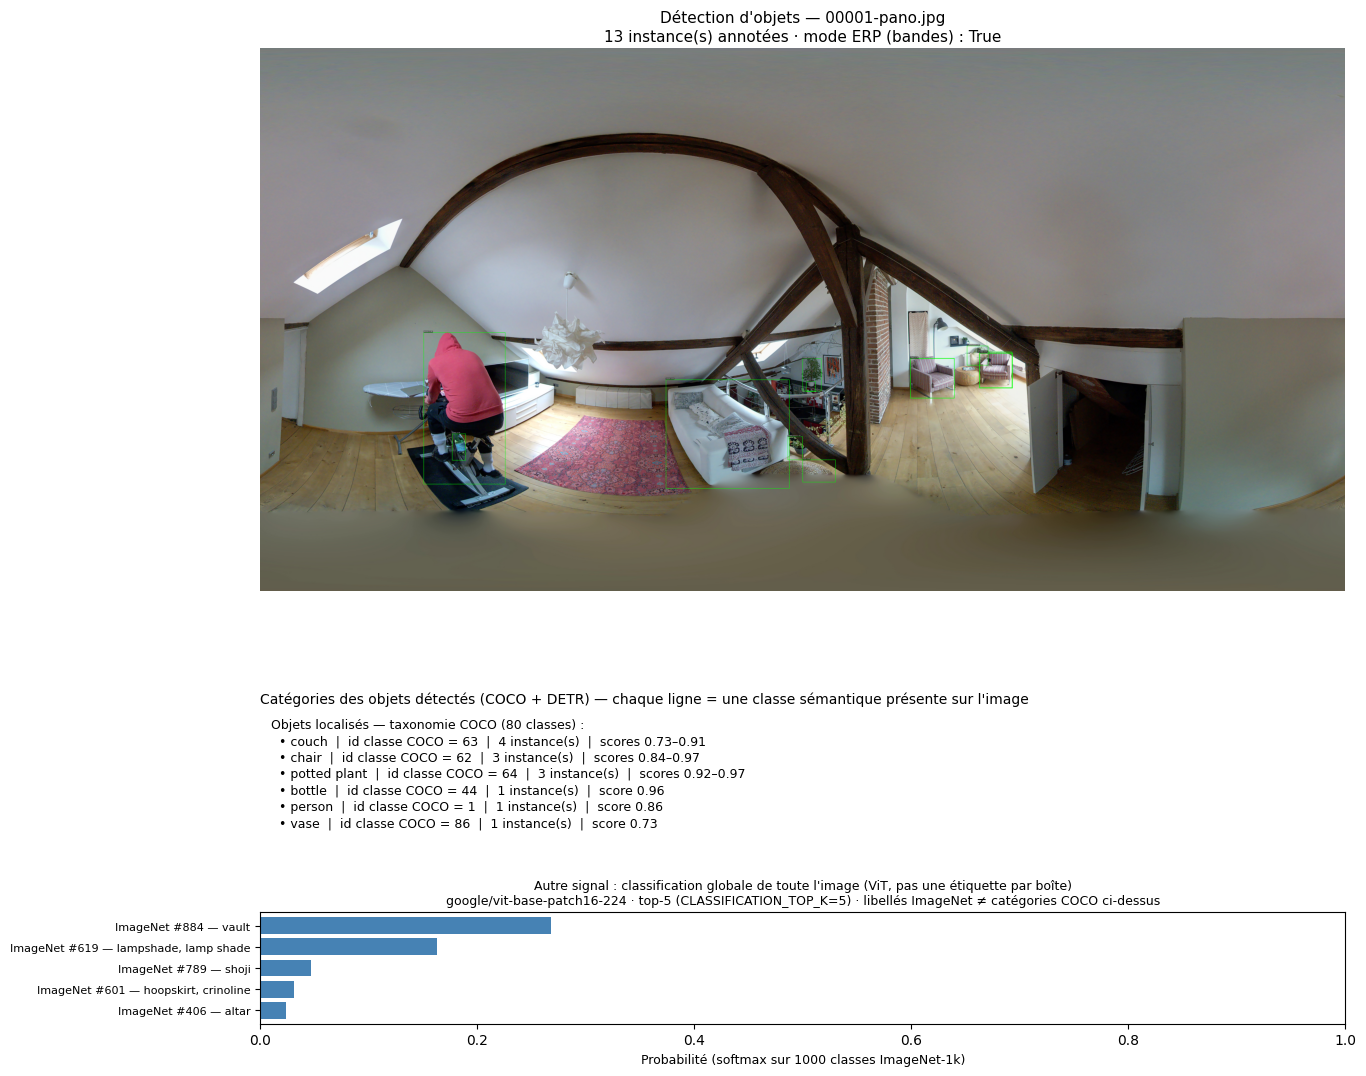

In [46]:
VIS_MAX_IMAGES = 6


def coco_category_summary_text(objects: list[dict]) -> str:
    """Pour chaque type d'objet détecté : nom de catégorie COCO, id de classe, nombre d'instances."""
    if not objects:
        return "Aucun objet au-dessus du seuil SCORE_THRESHOLD_DETR."
    by_label: dict[str, dict] = {}
    for o in objects:
        name = o["label"]
        lid = o["label_id"]
        if name not in by_label:
            by_label[name] = {"label_id": lid, "n": 0, "scores": []}
        by_label[name]["n"] += 1
        by_label[name]["scores"].append(o["score"])
    lines = ["Objets localisés — taxonomie COCO (80 classes) :"]
    for name in sorted(by_label.keys(), key=lambda k: (-by_label[k]["n"], k)):
        s = by_label[name]
        smin, smax = min(s["scores"]), max(s["scores"])
        score_part = f"scores {smin:.2f}–{smax:.2f}" if s["n"] > 1 else f"score {smax:.2f}"
        lines.append(
            f"  • {name}  |  id classe COCO = {s['label_id']}  |  {s['n']} instance(s)  |  {score_part}"
        )
    return "\n".join(lines)


try:
    _dinov3_list: list = list(dinov3_records)
except NameError:
    _dinov3_list = []
_d3_json_vis = OUTPUT_DIR / "dinov3_features.json"
if not _dinov3_list and _d3_json_vis.is_file():
    try:
        _dinov3_list = json.loads(_d3_json_vis.read_text(encoding="utf-8"))
        print("DINOv3 : données rechargées depuis", _d3_json_vis.name, "pour l’affichage.")
    except json.JSONDecodeError as _e:
        print("DINOv3 : JSON illisible —", _e)
dinov3_by_image = {r["image"]: r for r in _dinov3_list}
if ENABLE_DINOV3 and not dinov3_by_image:
    print(
        "DINOv3 activé mais aucune entrée (exécuter la cellule DINOv3 / vérifier HF gated + login, ou générer dinov3_features.json)."
    )

n_show = min(len(detection_records), VIS_MAX_IMAGES)
if n_show == 0:
    print("Aucune image à visualiser (exécutez d'abord les sections détection et classification).")
else:
    cls_by_image = {c["image"]: c for c in classification_records}
    for rec_det in detection_records[:n_show]:
        path = Path(rec_det["image"])
        im = load_pil_rgb(path)
        vis = draw_detections(im, rec_det["objects"])
        cls_rec = cls_by_image.get(rec_det["image"])
        d3 = dinov3_by_image.get(rec_det["image"]) if ENABLE_DINOV3 else None

        fig_w = 14.0
        ar = vis.size[0] / max(vis.size[1], 1)
        img_h_in = min(fig_w / ar, 12.0)
        extra_h = 3.2 if d3 else 0.0
        fig = plt.figure(figsize=(fig_w, img_h_in + 6.2 + extra_h))
        if d3:
            gs = fig.add_gridspec(
                4, 1, height_ratios=[img_h_in, 1.35, 1.25, 1.45], hspace=0.28
            )
        else:
            gs = fig.add_gridspec(3, 1, height_ratios=[img_h_in, 1.35, 1.25], hspace=0.28)
        ax_img = fig.add_subplot(gs[0, 0])
        ax_coco = fig.add_subplot(gs[1, 0])
        ax_bar = fig.add_subplot(gs[2, 0])

        ax_img.imshow(vis)
        ax_img.set_title(
            f"Détection d'objets — {path.name}\n"
            f"{len(rec_det['objects'])} instance(s) annotées · mode ERP (bandes) : {rec_det.get('erp_mode', False)}",
            fontsize=11,
        )
        ax_img.axis("off")

        ax_coco.axis("off")
        ax_coco.set_title(
            "Catégories des objets détectés (COCO + DETR) — chaque ligne = une classe sémantique présente sur l'image",
            fontsize=10,
            loc="left",
        )
        ax_coco.text(
            0.01,
            0.95,
            coco_category_summary_text(rec_det["objects"]),
            transform=ax_coco.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            linespacing=1.35,
        )

        if cls_rec:
            topk = cls_rec["topk"]
            scores = [t["score"] for t in topk]
            yticklabels = [f"ImageNet #{t['label_id']} — {t['label']}" for t in topk]
            y_pos = list(range(len(topk)))
            ax_bar.barh(y_pos, scores, color="steelblue")
            ax_bar.set_yticks(y_pos)
            ax_bar.set_yticklabels(yticklabels, fontsize=8)
            ax_bar.invert_yaxis()
            ax_bar.set_xlim(0, 1)
            k_show = len(topk)
            ax_bar.set_xlabel("Probabilité (softmax sur 1000 classes ImageNet-1k)", fontsize=9)
            ax_bar.set_title(
                "Autre signal : classification globale de toute l'image (ViT, pas une étiquette par boîte)\n"
                f"{VIT_MODEL_ID} · top-{k_show} (CLASSIFICATION_TOP_K={CLASSIFICATION_TOP_K}) · "
                "libellés ImageNet ≠ catégories COCO ci-dessus",
                fontsize=9,
            )
        else:
            ax_bar.axis("off")

        if d3:
            ax_dino = fig.add_subplot(gs[3, 0])
            grid = np.asarray(d3["patch_l2_grid"], dtype=np.float64)
            im_d = ax_dino.imshow(grid, cmap="magma", aspect="auto", vmin=0.0, vmax=1.0)
            ph, pw = d3.get("patch_grid_hw", [grid.shape[0], grid.shape[1]])
            inh, inw = d3.get("preprocess_input_hw", [None, None])
            ax_dino.set_title(
                "DINOv3 — carte des patchs (norme L2 normalisée par patch, sur l’image telle qu’entrée au réseau)\n"
                f"{d3.get('model', DINOV3_MODEL_ID)} · grille {ph}×{pw} · entrée {inh}×{inw} px · "
                f"embedding global dim={d3.get('embedding_dim')} · ||e||₂={d3.get('embedding_l2', float('nan')):.2f} · "
                "aucune catégorie texte — utile pour similarité / segmentation amont",
                fontsize=9,
            )
            ax_dino.set_xlabel("patch (colonnes)")
            ax_dino.set_ylabel("patch (lignes)")
            plt.colorbar(im_d, ax=ax_dino, fraction=0.035, pad=0.02, label="énergie relative")

        plt.tight_layout()
        plt.show()

### Visualisation DINOv3 (dédiée)

Trois vues par image : **aperçu RGB**, **carte d’énergie patch** (grille du backbone), **incrustation** de la carte redimensionnée (plus proche de la géométrie de la scène). Les données viennent de `dinov3_records` ou, à défaut, du fichier `dinov3_features.json` sur disque.

In [47]:
if not ENABLE_DINOV3:
    print("DINOv3 désactivé (ENABLE_DINOV3=False).")
else:
    try:
        _d3_vis_list: list = list(dinov3_records)
    except NameError:
        _d3_vis_list = []
    _d3_json_path = OUTPUT_DIR / "dinov3_features.json"
    if not _d3_vis_list and _d3_json_path.is_file():
        try:
            _d3_vis_list = json.loads(_d3_json_path.read_text(encoding="utf-8"))
            print("DINOv3 : lecture", _d3_json_path.name)
        except json.JSONDecodeError as exc:
            print("DINOv3 : impossible de lire le JSON —", exc)
            _d3_vis_list = []

    if not _d3_vis_list:
        print(
            "Aucune visualisation DINOv3 : exécuter la cellule d’inférence DINOv3 (accord HF + login si besoin)."
        )
    else:
        _Resample = getattr(Image, "Resampling", Image)
        _d3_n = min(len(_d3_vis_list), globals().get("VIS_MAX_IMAGES", 6))
        for rec in _d3_vis_list[:_d3_n]:
            p = Path(rec["image"])
            if not p.is_file():
                print("Fichier manquant, ignoré :", p)
                continue
            im = load_pil_rgb(p)
            grid = np.asarray(rec["patch_l2_grid"], dtype=np.float64)
            max_side = 800
            w, h = im.size
            thumb = im
            if max(w, h) > max_side:
                s = max_side / max(w, h)
                thumb = im.resize((max(1, int(w * s)), max(1, int(h * s))), _Resample.BILINEAR)
            tw, th = thumb.size
            energy_u8 = (np.clip(grid, 0.0, 1.0) * 255.0).astype(np.uint8)
            energy_up = Image.fromarray(energy_u8, mode="L").resize((tw, th), _Resample.NEAREST)

            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
            axes[0].imshow(thumb)
            axes[0].set_title(f"Image\n{p.name}", fontsize=10)
            axes[0].axis("off")

            im_g = axes[1].imshow(grid, cmap="magma", aspect="auto", vmin=0.0, vmax=1.0)
            ph, pw = rec.get("patch_grid_hw", list(grid.shape))
            axes[1].set_title(
                f"Carte patch (norme L2 normalisée)\ngrille {ph}×{pw}",
                fontsize=10,
            )
            axes[1].set_xlabel("patch (colonnes)")
            axes[1].set_ylabel("patch (lignes)")
            plt.colorbar(im_g, ax=axes[1], fraction=0.046, pad=0.02)

            axes[2].imshow(thumb)
            axes[2].imshow(energy_up, cmap="magma", alpha=0.52, vmin=0, vmax=255)
            emb_l2 = rec.get("embedding_l2", float("nan"))
            emb_d = rec.get("embedding_dim", "?")
            axes[2].set_title(
                f"Incrustation (heatmap → image, NN)\n||e||₂={emb_l2:.2f} · dim={emb_d}",
                fontsize=10,
            )
            axes[2].axis("off")

            fig.suptitle(
                f"DINOv3 — {rec.get('model', DINOV3_MODEL_ID)}",
                fontsize=11,
                y=1.05,
            )
            plt.tight_layout()
            plt.show()

Aucune visualisation DINOv3 : exécuter la cellule d’inférence DINOv3 (accord HF + login si besoin).


## 6) Panorama 360° — rappel sur le découpage (baseline)

- **Image équirectangulaire** : souvent **2:1** (largeur = 2 × hauteur). Les modèles type DETR supposent une perspective approximative ; aux **pôles** (haut/bas de l’image) la déformation est forte.
- **Baseline activée** si `USE_360_STRIPS` et ratio `largeur/hauteur ≥ ERP_ASPECT_MIN` : l’image est découpée en **`NUM_360_STRIPS` bandes verticales** de même largeur. Chaque bande est passée dans DETR ; les **bbox** sont **translatées** en coordonnées de l’image pleine (`+ strip_x0`).
- **Limites :** pas de fusion NMS sophistiquée entre bandes (un même objet peut apparaître sur deux bandes) ; pas de correction géométrique sphérique. Pour la prod, envisager **cube map**, **sliding windows** avec NMS, ou un modèle **fine-tuné** sur ERP.

La classification ViT utilise l’image **entière** ; pour l’ERP, le signal global est souvent biaisé — on peut classifier chaque bande de la même façon si besoin (extension). **DINOv3** (section 5bis) traite aussi l’image entière redimensionnée par le processor ; la carte patch reflète cette vue, pas le découpage ERP du DETR.

## 7) Limites et extensions

- **COCO (80 classes)** : meubles, personnes, véhicules courants — pas de vocabulaire métier BTP (prises, gaines, types de défauts) sans **fine-tuning** ou modèle **open-vocabulary** (OWL-ViT, Grounding DINO, etc.).
- **ImageNet (ViT)** : labels parfois peu interprétables pour une pièce ; traiter comme **indicateur auxiliaire**.
- **DINOv3** : pas de softmax sur des classes ; sortie = **vecteur global** + **carte patch** (normes). Checkpoints Meta souvent **gated** sur Hugging Face (login + acceptation des conditions). `dinov3_features.json` inclut un `embedding_preview` (8 valeurs) ; la grille `patch_l2_grid` est exportée en entier ; le vecteur complet peut être recalculé en ré-exécutant la cellule DINOv3 si besoin pour du clustering.
- **Performance :** premier run télécharge les poids depuis Hugging Face (cache utilisateur, variable d’environnement `HF_HOME`).

Fichiers générés dans `inference_outputs/` :
- `det_*.png` — visualisation des détections
- `detections.json` — liste structurée par image
- `classifications.json` — top-K ImageNet par image
- `dinov3_features.json` / `dinov3_patch_energy_*.png` — si DINOv3 activé et chargé

Dans le notebook, la section **Visualisation de l'inférence** regroupe détections, récap COCO, scores ImageNet et (si disponible) la heatmap DINOv3.